In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#importing the 2025 csv ttc subway delay data as a pandas dataframe
df_2025 = pd.read_csv('C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/raw/csv/ttc-subway-delay-data-2025.csv')

#Adding a new column that is a formatted Year Column into data type Date rather than a string
df_2025['Formatted Date'] = pd.to_datetime(df_2025['Date'])

#Extracted Year, Month, and Day from Date
df_2025['Year'] = df_2025['Formatted Date'].dt.year
df_2025['Month'] = df_2025['Formatted Date'].dt.month
df_2025['Day of the Month'] = df_2025['Formatted Date'].dt.day

#Formatted time from string to time and extracting hour of day
df_2025['Formatted Time'] = pd.to_datetime(df_2025['Time'], format='%H:%M').dt.time
df_2025['Hour'] = pd.to_datetime(df_2025['Time'], format='%H:%M').dt.hour 

df_2025.info()

<class 'pandas.DataFrame'>
RangeIndex: 25713 entries, 0 to 25712
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                25713 non-null  int64         
 1   Date              25713 non-null  str           
 2   Time              25713 non-null  str           
 3   Day               25713 non-null  str           
 4   Station           25713 non-null  str           
 5   Code              25713 non-null  str           
 6   Min Delay         25713 non-null  int64         
 7   Min Gap           25713 non-null  int64         
 8   Bound             16251 non-null  str           
 9   Line              25646 non-null  str           
 10  Vehicle           25713 non-null  int64         
 11  Formatted Date    25713 non-null  datetime64[us]
 12  Year              25713 non-null  int32         
 13  Month             25713 non-null  int32         
 14  Day of the Month  25713 non-null 

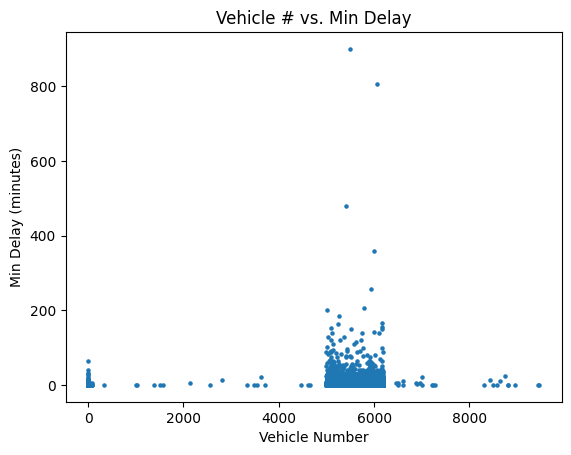

In [ ]:
#Plotting Min Delay vs Vehicle Number with raw uneditted data
plt.xlabel('Vehicle Number')
plt.ylabel('Min Delay (minutes)')
plt.title('Vehicle # vs. Min Delay')
plt.scatter(df_2025["Vehicle"], df_2025["Min Delay"], s=5)

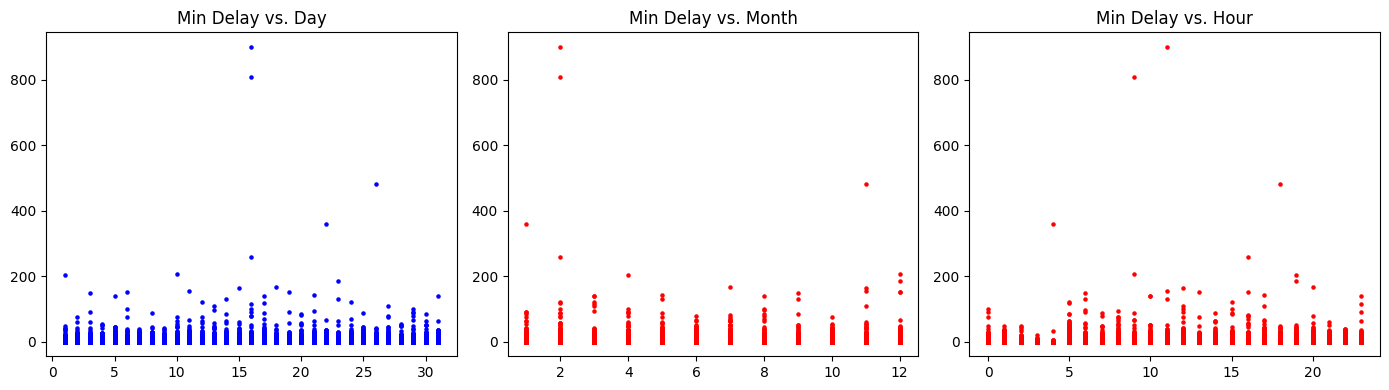

In [ ]:
#Plotting Min Delay vs Day, Month, Hour with raw data

y = df_2025["Min Delay"]


# Create a figure and a 2x2 grid of axes
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 4))

# Plot data on each subplot
axs[0].scatter(df_2025['Day'], y, c='blue', s=5)
axs[0].set_title('Min Delay vs. Day')

axs[1].scatter(df_2025['Month'], y, color='red', s=5)
axs[1].set_title('Min Delay vs. Month')

axs[2].scatter(df_2025['Hour'], y, color='red', s=5)
axs[2].set_title('Min Delay vs. Hour')
# Adjust layout to prevent overlapping titles and labels
fig.tight_layout()

# Display the figure
plt.show()


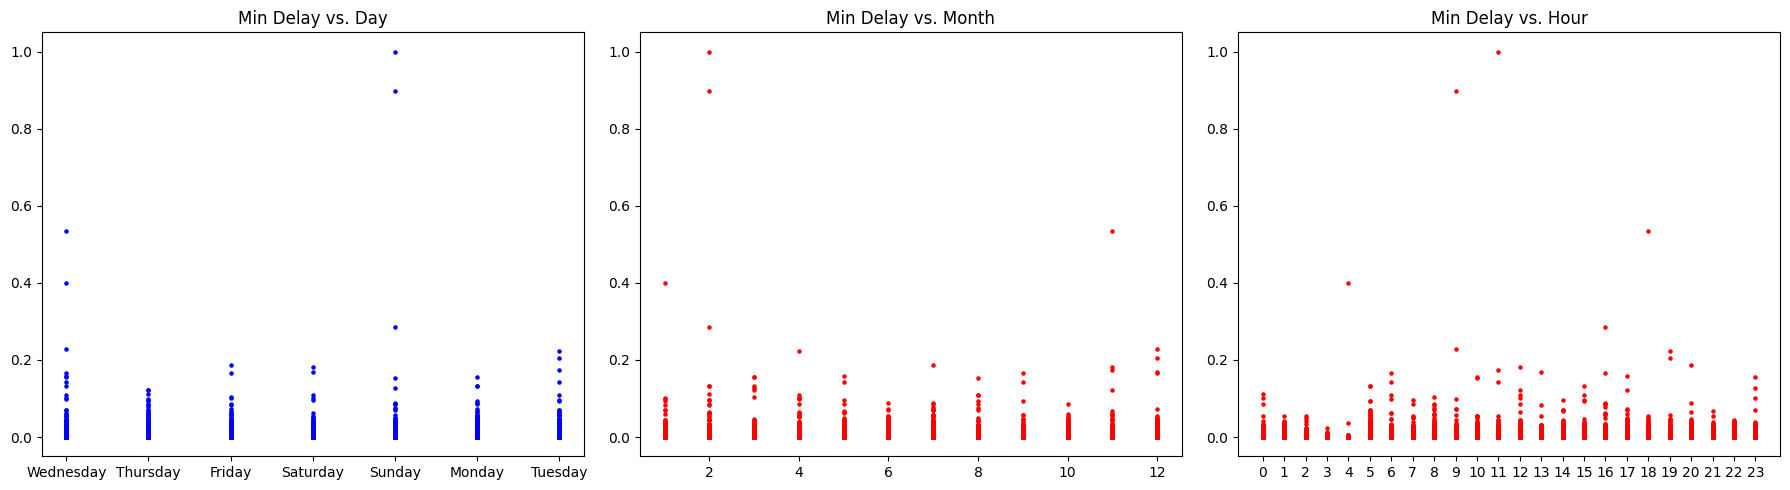

In [ ]:
y2 = df_2025["Min Delay"]/900

# Create a figure and a 2x2 grid of axes
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Plot data on each subplot
axs[0].scatter(df_2025['Day'], y2, c='blue', s=5)
axs[0].set_title('Min Delay vs. Day')

axs[1].scatter(df_2025['Month'], y2, color='red', s=5)
axs[1].set_title('Min Delay vs. Month')

axs[2].scatter(df_2025['Hour'], y2, color='red', s=5) #this is not a great plot as, for example, anything >2 and <3, it would be considered 2 pm
axs[2].set_title('Min Delay vs. Hour')
axs[2].set_xticks(range(0, 24))
# Adjust layout to prevent overlapping titles and labels
fig.tight_layout()

# Display the figure
plt.show()

Minute Delay Averge (grouped by month): Month
1     3.032795
2     3.865079
3     3.176322
4     2.860179
5     2.499770
6     2.637629
7     2.638850
8     1.887008
9     2.307565
10    2.540701
11    2.802083
12    2.880464
Name: Min Delay, dtype: float64



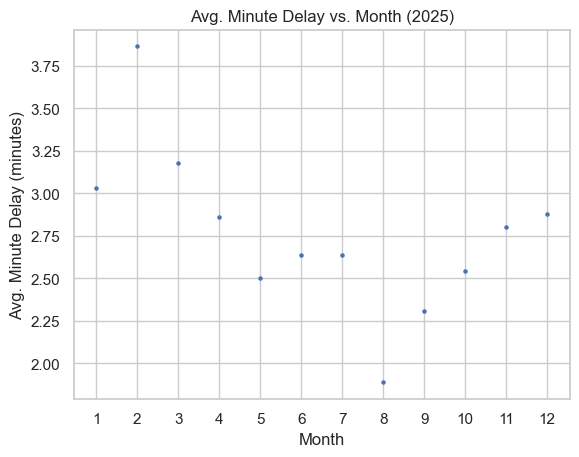

In [ ]:
# This code will aim to try and calculate the average min delay per month in 2025 and plot the results

daily_avg_groupby = df_2025.groupby(df_2025['Month'])['Min Delay'].mean()
print(f"Minute Delay Averge (grouped by month): {df_2025.groupby(df_2025['Month'])['Min Delay'].mean()}\n")
#print(f"Minute Delay Median (grouped by month): {df_2025.groupby(df_2025['Month'])['Min Delay'].median()}")

#Plotting Average Delay Time vs Month with raw uneditted data
plt.xlabel('Month')
plt.ylabel('Avg. Minute Delay (minutes)')
plt.xticks(df_2025['Month'].unique())
plt.title('Avg. Minute Delay vs. Month (2025)')
plt.scatter((df_2025['Month'].unique()), daily_avg_groupby, s=5)
plt.show()


Min Delay Averge (grouped by Day of week): <StringArray>
['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday']
Length: 7, dtype: str


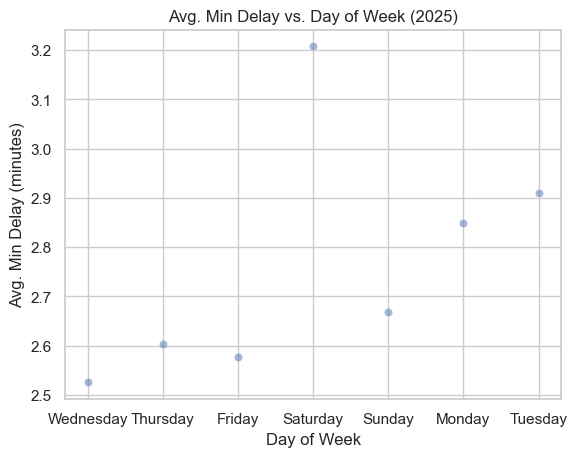

In [ ]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per day of the week in 2025

dayofweek_avg_groupby = df_2025.groupby(df_2025['Day'])['Min Delay'].mean()
print(f"Min Delay Averge (grouped by Day of week): {df_2025['Day'].unique()}")

# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")

#Plotting Average Delay Time vs Month with raw uneditted data
sns.scatterplot(x=df_2025['Day'].unique(), y=dayofweek_avg_groupby, alpha=0.5)
plt.xlabel('Day of Week')
plt.ylabel('Avg. Min Delay (minutes)')
plt.title('Avg. Min Delay vs. Day of Week (2025)')
#plt.scatter((df_2025['Day'].unique()), dayofweek_avg_groupby, s=7)
#plt.grid(True)
plt.show()

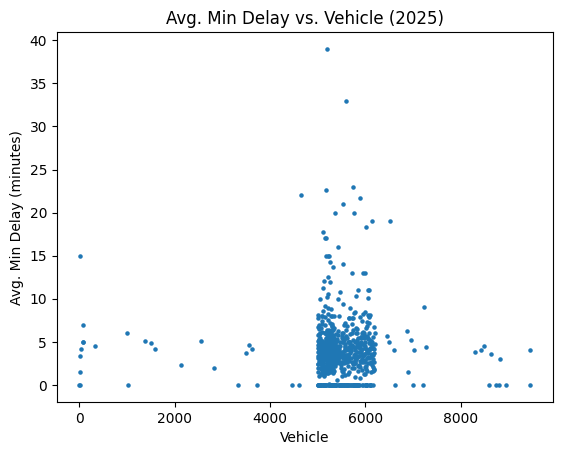

In [12]:
# This code will aim to try and calculate the average min delay Vehicle in 2025

vehicle_avg_groupby = df_2025.groupby(df_2025['Vehicle'])['Min Delay'].mean()
#print(f"Min Delay Averge (grouped by Vehicle): {df_2025['Vehicle'].unique()}")

#Plotting Average Delay Time vs Month with raw uneditted data
plt.xlabel('Vehicle')
plt.ylabel('Avg. Min Delay (minutes)')
plt.title('Avg. Min Delay vs. Vehicle (2025)')
plt.scatter((df_2025['Vehicle'].unique()), vehicle_avg_groupby, s=5)


##Might be something wrong here!

In [ ]:
#This code aims to showcase the top5 stations with the highest total incidents, the total min delay, and the average delay per incident

# Filter only rows with actual delays
delays_df = df_2025[df_2025["Min Delay"] > 0].copy()
#delays_df = df

# Group by station and calculate delay metrics
station_delay_summary = delays_df.groupby("Station").agg(
    Total_Incidents=("Min Delay", "count"),
    Total_Min_Delay=("Min Delay", "sum"),
    Avg_Delay_Per_Incident=("Min Delay", "mean")
).sort_values(by="Total_Incidents", ascending=False)

#Round average delay
station_delay_summary["Avg_Delay_Per_Incident"] = station_delay_summary["Avg_Delay_Per_Incident"].round(2)

#Display top 5 stations with most delay incidents
station_delay_summary.head(5)

,Total_Incidents,Total_Min_Delay,Avg_Delay_Per_Incident
Station,,,
WILSON STATION,369,2198,5.96
KIPLING STATION,360,2281,6.34
KENNEDY BD STATION,346,2232,6.45
FINCH STATION,315,1826,5.80
BLOOR STATION,288,1783,6.19


In [11]:
#This code aims to showcase the top5 stations with the highest total incidents, the total min delay, and the average delay per incident when zero delays are taken out

# Filter only rows with actual delays
#delays_df = df_2025[df_2025["Min Delay"] > 0].copy()
delays_df = df_2025

# Group by station and calculate delay metrics
station_delay_summary = delays_df.groupby("Station").agg(
    Total_Incidents=("Min Delay", "count"),
    Total_Min_Delay=("Min Delay", "sum"),
    Avg_Delay_Per_Incident=("Min Delay", "mean")
).sort_values(by="Total_Incidents", ascending=False)

#Round average delay
station_delay_summary["Avg_Delay_Per_Incident"] = station_delay_summary["Avg_Delay_Per_Incident"].round(2)

#Display top stations with most delay incidents
station_delay_summary.head(15)

,Total_Incidents,Total_Min_Delay,Avg_Delay_Per_Incident
Station,,,
KENNEDY BD STATION,991,2232,2.25
BLOOR STATION,924,1783,1.93
FINCH STATION,898,1826,2.03
KIPLING STATION,870,2281,2.62
EGLINTON STATION,666,2851,4.28
WILSON STATION,633,2198,3.47
UNION STATION,593,1495,2.52
WARDEN STATION,573,1613,2.82
DUNDAS STATION,525,913,1.74


Available station names (sample): ['KENNEDY BD STATION', 'BLOOR STATION', 'FINCH STATION', 'KIPLING STATION', 'EGLINTON STATION', 'WILSON STATION', 'UNION STATION', 'WARDEN STATION', 'DUNDAS STATION', 'YONGE BD STATION']


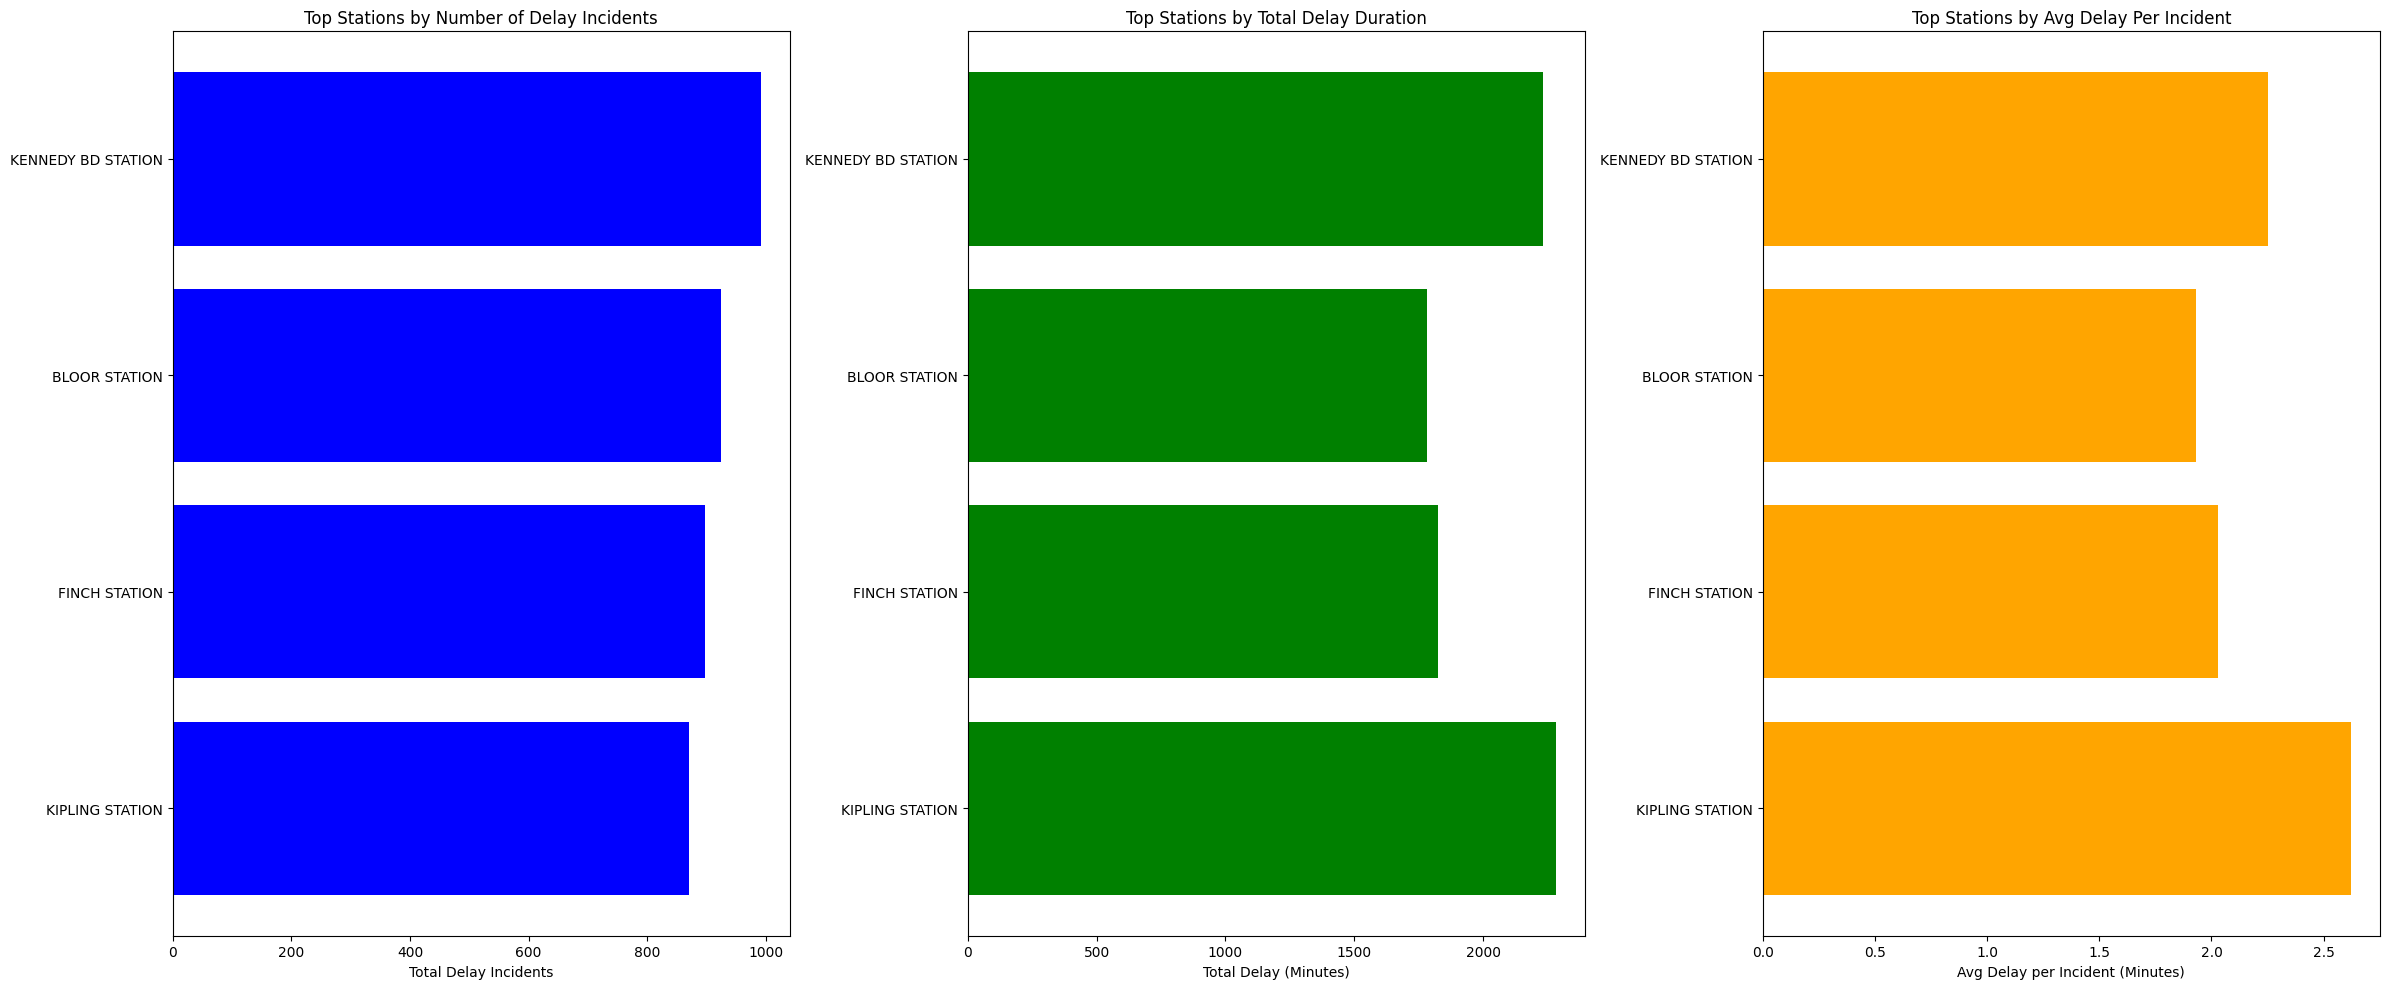

In [19]:
# Step 1: Get top 5 stations by Total_Incidents
top_stations = station_delay_summary.sort_values(by="Total_Incidents", ascending=False).head(4)

# Step 2: Check UNION STATION's presence and spelling
print("Available station names (sample):", station_delay_summary.index.tolist()[:10])  # See what's in the index


# Step 4: Plotting
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
stations_reversed = top_stations.index[::-1]

# Total Incidents
axes[0].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Incidents"], color='blue')
axes[0].set_xlabel("Total Delay Incidents")
axes[0].set_title("Top Stations by Number of Delay Incidents")

# Total Delay
axes[1].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Min_Delay"], color='green')
axes[1].set_xlabel("Total Delay (Minutes)")
axes[1].set_title("Top Stations by Total Delay Duration")

# Avg Delay
axes[2].barh(stations_reversed, top_stations.loc[stations_reversed]["Avg_Delay_Per_Incident"], color='orange')
axes[2].set_xlabel("Avg Delay per Incident (Minutes)")
axes[2].set_title("Top Stations by Avg Delay Per Incident")


# Save before showing
plt.tight_layout()
plt.savefig("top_stations_with_delays.png", dpi=300, bbox_inches='tight')  # Save first
plt.show()  # Then show